In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [2]:
import pandas as pd
#读取数据
df=pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')

In [3]:
#取头部文件感觉一般是前五项
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
#一共8807行12列
df.shape

(8807, 12)

In [5]:
#可以快速知道哪些列有缺失值
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

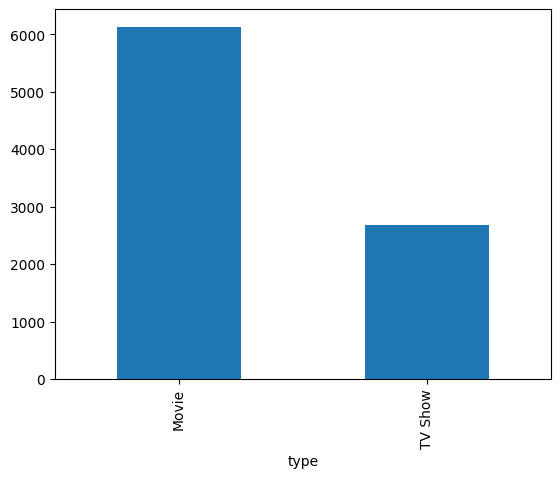

In [7]:
import matplotlib.pyplot as plt
df['type'].value_counts().plot(kind="bar")
plt.show()

In [8]:
df["country"].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [9]:
df["release_year"].value_counts().head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

In [10]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

把国家数量的前十画出来

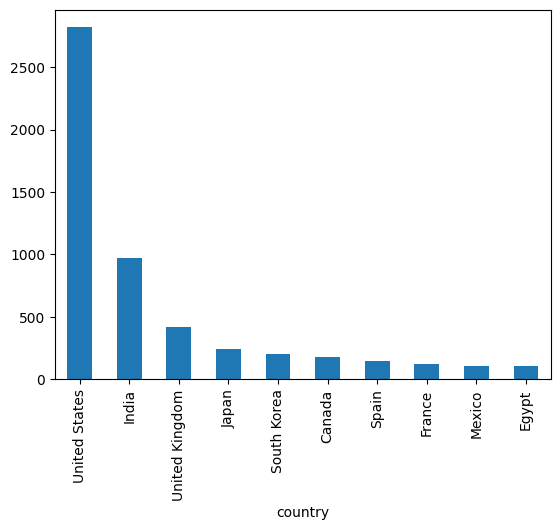

In [11]:
country_counts=df["country"].value_counts().head(10)
country_counts.plot(kind="bar")
plt.show()

In [12]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [13]:
df["director"].isnull().sum()#sum是Numpy里的所以最后是np类型的

np.int64(2634)

In [14]:
type(df)

pandas.core.frame.DataFrame

In [15]:
df = df.fillna({"director": "Unknown"})

In [16]:
type(df)

pandas.core.frame.DataFrame

In [17]:
print(df["director"].isnull().sum())

0


In [18]:
df_real=df[df["director"]!="Unknown"]#df["director"]!="Unknown"是bool Seires
top10=df_real["director"].value_counts().head(10)#df_real["director"]所以这个是Series
print(top10)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


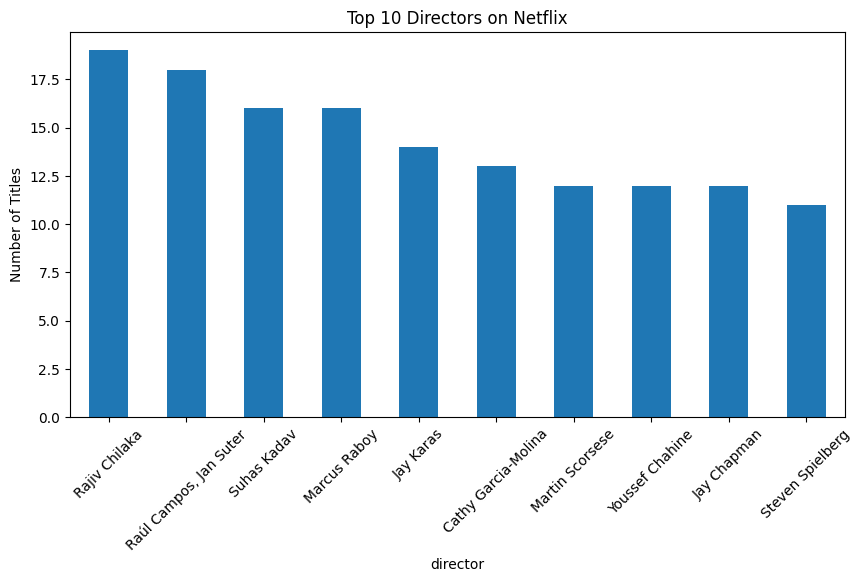

In [19]:
import matplotlib.pyplot as plt
top10.plot(kind="bar",figsize=(10,5))
plt.xticks(rotation=45)  # 让导演名字倾斜，防止重叠
plt.ylabel("Number of Titles")
plt.title("Top 10 Directors on Netflix")
plt.show()

Netflix一共有多少部Movie

In [20]:
type_diff=df["type"].value_counts()

In [21]:
type_diff["Movie"]

np.int64(6131)

In [22]:
i=type_diff["Movie"]/type_diff["TV Show"]
print(f"Movie是TV Show 的{i:.2f}倍")

Movie是TV Show 的2.29倍


统计：Netflix作品数量最多的前10个国家

In [23]:
df["country"].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

把前10国家画成柱状图

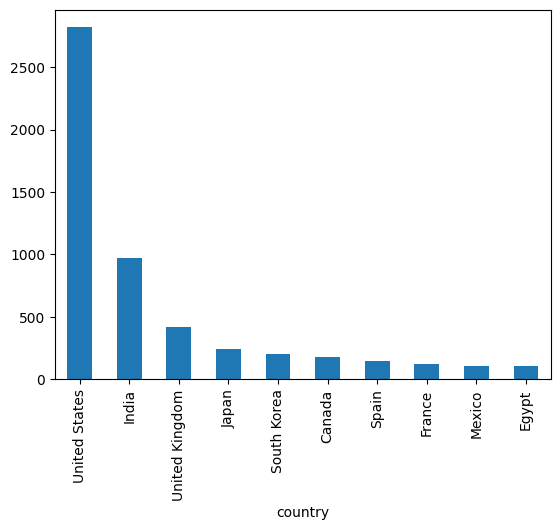

In [24]:
df["country"].value_counts().head(10).plot(kind="bar")
plt.show()

**！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！**

**组合分析：前10个国家里每个国家Movie和TV Show的数量是多少**

In [25]:
type(df.groupby("country"))#按国家的不同分组

pandas.core.groupby.generic.DataFrameGroupBy

In [26]:
df.groupby("country").size()#先按国家分组在统计每组有多少条记录

country
, France, Algeria                                       1
, South Korea                                           1
Argentina                                              56
Argentina, Brazil, France, Poland, Germany, Denmark     1
Argentina, Chile                                        2
                                                       ..
Venezuela                                               1
Venezuela, Colombia                                     1
Vietnam                                                 7
West Germany                                            1
Zimbabwe                                                1
Length: 748, dtype: int64

In [27]:
df["country"].value_counts()#统计country这列里每个国家出现了多少次

country
United States                                                      2818
India                                                               972
United Kingdom                                                      419
Japan                                                               245
South Korea                                                         199
                                                                   ... 
Mexico, United States, Spain, Colombia                                1
Canada, Norway                                                        1
Finland, Germany, Belgium                                             1
Argentina, United States, Mexico                                      1
United Kingdom, United States, Germany, Denmark, Belgium, Japan       1
Name: count, Length: 748, dtype: int64

In [28]:
df.groupby(["country","type"]).size().reset_index(name="count")

,country,type,count
0,", France, Algeria",Movie,1
1,", South Korea",TV Show,1
2,Argentina,Movie,38
3,Argentina,TV Show,18
4,"Argentina, Brazil, France, Poland, Germany, De...",Movie,1
...,...,...,...
842,Venezuela,Movie,1
843,"Venezuela, Colombia",Movie,1
844,Vietnam,Movie,7
845,West Germany,Movie,1



****将前10国家的Movie/TV Show数量统计并画出柱状图****

In [29]:
country_counts=df["country"].value_counts()
top10_c=country_counts.head(10).index#只保留国家名字好比较
print(top10_c)

Index(['United States', 'India', 'United Kingdom', 'Japan', 'South Korea',
       'Canada', 'Spain', 'France', 'Mexico', 'Egypt'],
      dtype='object', name='country')


In [30]:
df_top10=df[df["country"].isin(top10_c)]#里面的返回一个Bool Series
#df[...]只保留True的行这是行筛选机制

In [31]:
grouped=df_top10.groupby(["country","type"]).size()#这是按国家名字排序这个是Series因为索引变成了（country，type）
print(grouped)#head(10)是记录前10条记录而不是前十个国家

country         type   
Canada          Movie       122
                TV Show      59
Egypt           Movie        92
                TV Show      14
France          Movie        75
                TV Show      49
India           Movie       893
                TV Show      79
Japan           Movie        76
                TV Show     169
Mexico          Movie        70
                TV Show      40
South Korea     Movie        41
                TV Show     158
Spain           Movie        97
                TV Show      48
United Kingdom  Movie       206
                TV Show     213
United States   Movie      2058
                TV Show     760
dtype: int64


In [32]:
table=grouped.unstack()#这一步是把类型变成列方便画图来着
print(table)

type            Movie  TV Show
country                       
Canada            122       59
Egypt              92       14
France             75       49
India             893       79
Japan              76      169
Mexico             70       40
South Korea        41      158
Spain              97       48
United Kingdom    206      213
United States    2058      760


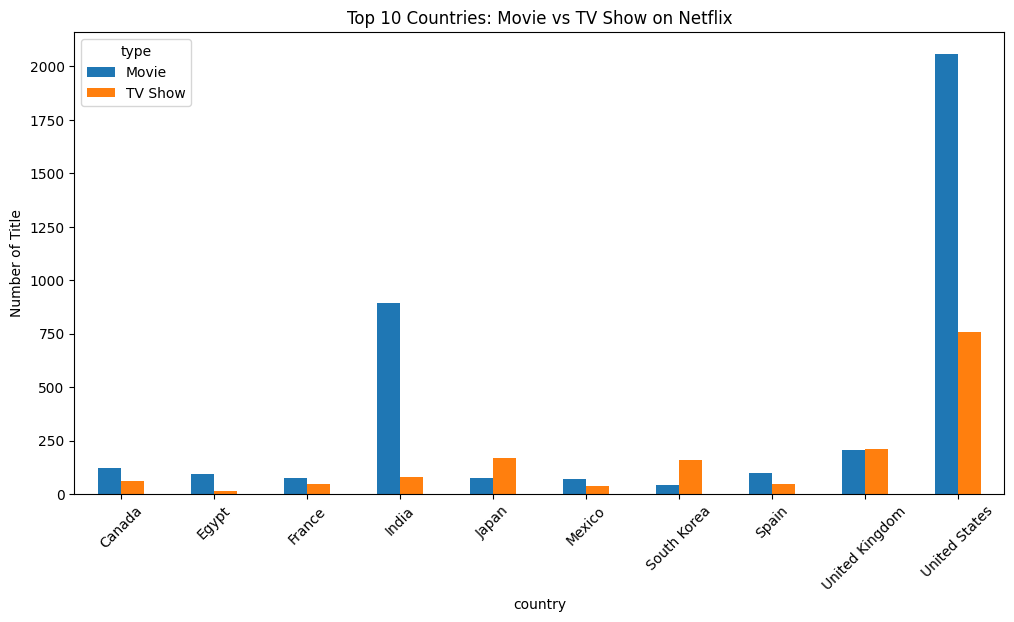

In [33]:
table.plot(kind="bar",figsize=(12,6))
plt.xticks(rotation=45)
plt.ylabel("Number of Title")
plt.title("Top 10 Countries: Movie vs TV Show on Netflix")
plt.show()

**注意sort_index()和sort_values()是不一样的！**


**1. 读取数据 → pd.read_csv()2. 查看数据 → head() / info() / shape()3. 处理缺失值 → fillna()4. 单列统计 → value_counts() / .size()5. 多列统计 → groupby([...]).size().unstack()6. 排序 → sort_values()7. 可视化 → plot(kind="bar") / plt.show()8. 写结论 → 分析趋势**



In [34]:
top10_c=df["country"].value_counts().head(10).index#top_10就是国家集合
df_top10=df[df["country"].isin(top10_c)]#df_top10可能就是国家加其他信息的集合
print(top10_c)

grouped=df_top10.groupby(["country","type"]).size()
print(grouped)

Index(['United States', 'India', 'United Kingdom', 'Japan', 'South Korea',
       'Canada', 'Spain', 'France', 'Mexico', 'Egypt'],
      dtype='object', name='country')
country         type   
Canada          Movie       122
                TV Show      59
Egypt           Movie        92
                TV Show      14
France          Movie        75
                TV Show      49
India           Movie       893
                TV Show      79
Japan           Movie        76
                TV Show     169
Mexico          Movie        70
                TV Show      40
South Korea     Movie        41
                TV Show     158
Spain           Movie        97
                TV Show      48
United Kingdom  Movie       206
                TV Show     213
United States   Movie      2058
                TV Show     760
dtype: int64


In [35]:
table=grouped.unstack()
print(table)

type            Movie  TV Show
country                       
Canada            122       59
Egypt              92       14
France             75       49
India             893       79
Japan              76      169
Mexico             70       40
South Korea        41      158
Spain              97       48
United Kingdom    206      213
United States    2058      760


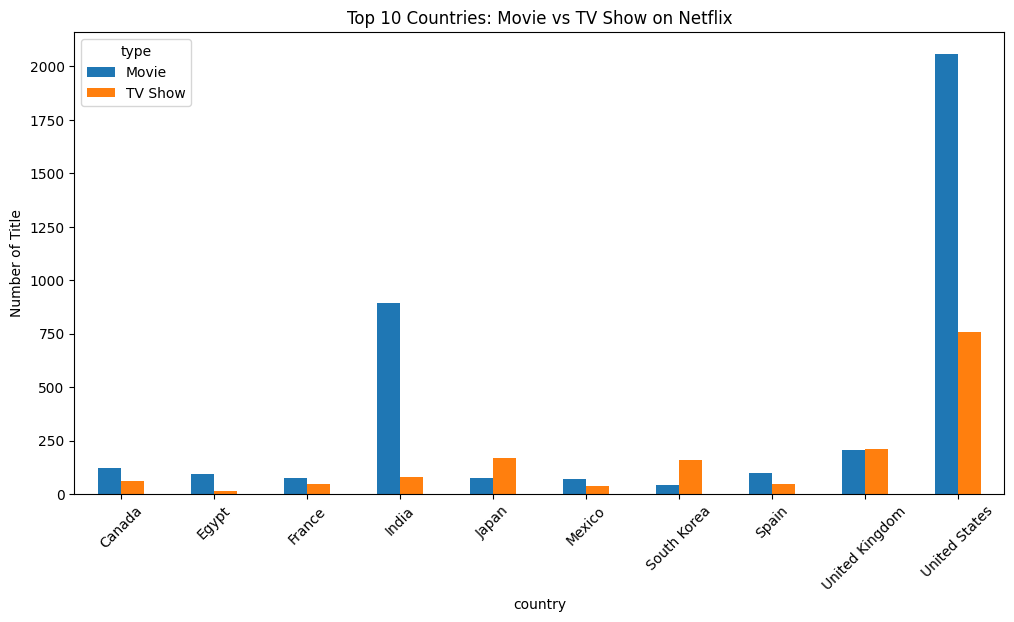

In [36]:
import matplotlib.pyplot as plt
table.plot(kind="bar",figsize=(12,6))
plt.xticks(rotation=45)
plt.ylabel("Number of Title")
plt.title("Top 10 Countries: Movie vs TV Show on Netflix")
plt.show()

**接下来是对agg的练习**

In [37]:
# 按 type 分组统计 release_year
grouped_type = df.groupby("type")["release_year"]#按照type分组分析release_year列
status_type=grouped_type.agg(["count","mean","max"])#聚合多个统计方法
print(status_type)

         count         mean   max
type                             
Movie     6131  2013.121514  2021
TV Show   2676  2016.605755  2021


In [38]:
top10_c=df["country"].value_counts().head(10).index
df_top10=df[df["country"].isin(top10_c)]

In [39]:
status_country_type=df_top10.groupby(["country","type"])["release_year"].agg(["count","mean","max"])
print(status_country_type)

                        count         mean   max
country        type                             
Canada         Movie      122  2016.500000  2020
               TV Show     59  2016.220339  2021
Egypt          Movie       92  2007.663043  2020
               TV Show     14  2018.071429  2021
France         Movie       75  2016.600000  2021
               TV Show     49  2017.122449  2021
India          Movie      893  2011.484882  2021
               TV Show     79  2017.405063  2021
Japan          Movie       76  2013.381579  2021
               TV Show    169  2014.692308  2021
Mexico         Movie       70  2015.900000  2021
               TV Show     40  2016.550000  2021
South Korea    Movie       41  2017.658537  2021
               TV Show    158  2016.993671  2021
Spain          Movie       97  2017.577320  2021
               TV Show     48  2018.708333  2021
United Kingdom Movie      206  2014.597087  2021
               TV Show    213  2015.873239  2021
United States  Movie

In [40]:
table=status_country_type.unstack()
print(table)

               count                 mean                max        
type           Movie TV Show        Movie      TV Show Movie TV Show
country                                                             
Canada           122      59  2016.500000  2016.220339  2020    2021
Egypt             92      14  2007.663043  2018.071429  2020    2021
France            75      49  2016.600000  2017.122449  2021    2021
India            893      79  2011.484882  2017.405063  2021    2021
Japan             76     169  2013.381579  2014.692308  2021    2021
Mexico            70      40  2015.900000  2016.550000  2021    2021
South Korea       41     158  2017.658537  2016.993671  2021    2021
Spain             97      48  2017.577320  2018.708333  2021    2021
United Kingdom   206     213  2014.597087  2015.873239  2021    2021
United States   2058     760  2012.058795  2016.715789  2021    2021


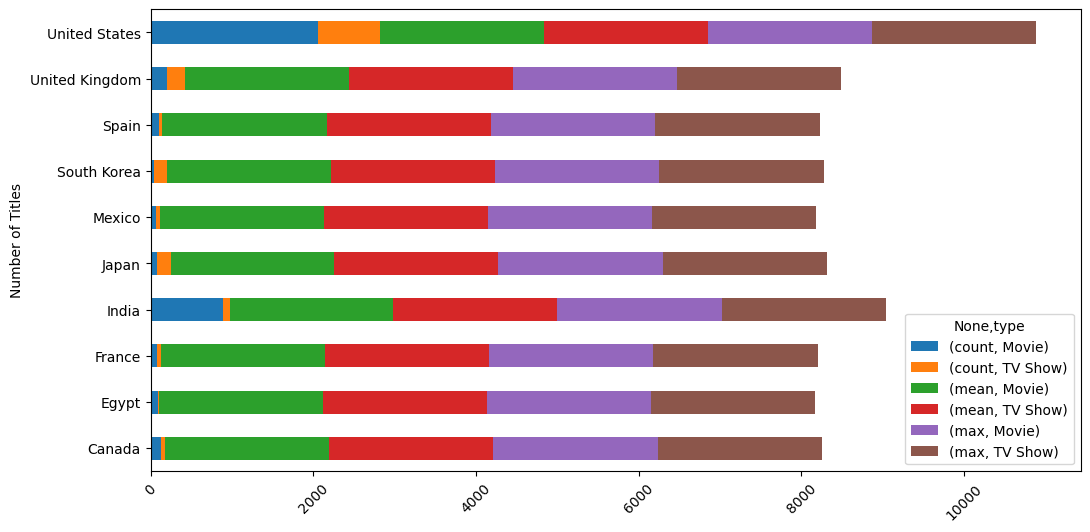

In [41]:
import matplotlib.pyplot as plt
table.plot(kind="barh",stacked=True,figsize=(12,6))
#stacked=True横向堆叠如果没有则是并排摆放
plt.xticks(rotation=45)
plt.ylabel("Number of Titles")
plt.show()

*————————————————————————————————————————————————————*

In [42]:
df.groupby("type")["release_year"].mean()

type
Movie      2013.121514
TV Show    2016.605755
Name: release_year, dtype: float64

In [43]:
df.groupby("type")["release_year"].max()

type
Movie      2021
TV Show    2021
Name: release_year, dtype: int64

In [44]:
df.groupby("type")["release_year"].min()

type
Movie      1942
TV Show    1925
Name: release_year, dtype: int64

**apply()的学习**

In [45]:
df["release_year_plus1"]=df["release_year"].apply(lambda x:x+1)
df[["release_year","release_year_plus1"]].head()
#匿名函数  lambda 参数：表达式
#相当于 def add1(x):
#          return x+1

,release_year,release_year_plus1
0,2020,2021
1,2021,2022
2,2021,2022
3,2021,2022
4,2021,2022


In [46]:
df["director_upper"]=df["director"].apply(lambda x:x.upper())
df[["director","director_upper"]].head()

,director,director_upper
0,Kirsten Johnson,KIRSTEN JOHNSON
1,Unknown,UNKNOWN
2,Julien Leclercq,JULIEN LECLERCQ
3,Unknown,UNKNOWN
4,Unknown,UNKNOWN


In [47]:
def categorize_year(year):
    if year<2010:
        return "old"
    elif year<2018:
        return "mid"
    else:
        return "new"
df["year_category"]=df["release_year"].apply(categorize_year)
df[["release_year","year_category"]].head()

,release_year,year_category
0,2020,new
1,2021,new
2,2021,new
3,2021,new
4,2021,new


In [48]:
df["title_len"]=df.apply(lambda row:len(str(row["title"]))+len(str(row["director"])),axis=1)
#apply内部的参数:axis=1按行操作;axis=0按列操作
#str(...)变字符串
#len(...)统计长度
print(df["title_len"])

0       35
1       20
2       24
3       28
4       19
        ..
8802    19
8803    18
8804    25
8805    16
8806    17
Name: title_len, Length: 8807, dtype: int64


In [49]:
df["is_recent"]=df.apply(
    lambda row: row["release_year"]>=2018,
    axis=1
)
print(df["is_recent"])

0        True
1        True
2        True
3        True
4        True
        ...  
8802    False
8803     True
8804    False
8805    False
8806    False
Name: is_recent, Length: 8807, dtype: bool


In [50]:
df["title_words"]=df.apply(lambda row:len(row["title"].split()),axis=1)
print(df["title_words"])#df["title"]调用apply，也传入了“title”给row

0       4
1       3
2       1
3       3
4       2
       ..
8802    1
8803    2
8804    1
8805    1
8806    1
Name: title_words, Length: 8807, dtype: int64


In [51]:
#两种apply
#Series.apply:(参数拿到的是一个值不需要调用其中的一个)
#df["title"].apply(...)
#DataFrame.apply:(参数拿到的是一行值,需要用什么就调用什么)
#df.apply(...,axis=1)

**apply和groupby联合作战**

In [52]:
df.groupby("type")["title_words"].mean()

type
Movie      3.188876
TV Show    2.931988
Name: title_words, dtype: float64

In [53]:
df["age"] = df["release_year"].apply(
    lambda x: 2026-x
)
print(df["age"])

0        6
1        5
2        5
3        5
4        5
        ..
8802    19
8803     8
8804    17
8805    20
8806    11
Name: age, Length: 8807, dtype: int64


**使用def做更复杂的实现**

In [54]:
def age_judge(x):
    if x<5:
        return "recent"
    elif 5<=x<10:
        return "mid"
    else:
        return "old"
df["age_category"]=df["age"].apply(age_judge)
print(df["age_category"].head())

0    mid
1    mid
2    mid
3    mid
4    mid
Name: age_category, dtype: object


In [55]:
df["age_category"].value_counts()

age_category
mid    4754
old    4053
Name: count, dtype: int64

In [56]:
#需要弄清楚的三个
#df["age_category"].value_counts()
#统计age_category每个类别出现的次数

#df[df["age_category"]=="mid"]
#df["age_category"]=="mid"布尔筛选
#df[布尔Series]返回一个DataFrame,所有age_category等于mid的行

#len(df[df["age_category"]=="mid"])
#返回的是DataFrame的行数

In [57]:
#bool Series 返回类型DataFrame含义是筛选行

In [58]:
df.groupby("type")["title_words"].value_counts().unstack()


title_words,1,2,3,4,5,6,7,8,9,10,11,12,13,15,16,17
type,,,,,,,,,,,,,,,,
Movie,1148.0,1515.0,1322.0,875.0,532.0,338.0,199.0,95.0,58.0,28.0,9.0,4.0,3.0,3.0,1.0,1.0
TV Show,480.0,812.0,607.0,357.0,217.0,110.0,37.0,33.0,14.0,6.0,1.0,1.0,NaN,NaN,1.0,NaN


In [59]:
def lei(x):
    if (2026-x)<5:
        return "recent"
    elif 5<(2026-x)<10:
        return "mid"
    else :
        return "old"

df["age_category"] = df["release_year"].apply(lei)
df["age_category"].value_counts()

age_category
old    4645
mid    4162
Name: count, dtype: int64

**MERGE**

In [60]:
import pandas as pd
student=pd.DataFrame({
    "id":[1,2,3],
    "name":["Tom","Jack","Lucy"]
    
})
student


,id,name
0,1,Tom
1,2,Jack
2,3,Lucy


In [61]:
score = pd.DataFrame({
    "id":[1,2,3],
    "score":[90,85,100]
})

score

,id,score
0,1,90
1,2,85
2,3,100


In [62]:
student.merge(score,on="id")#on表示按照哪一行匹配的
#merge是DataFrame的方法

,id,name,score
0,1,Tom,90
1,2,Jack,85
2,3,Lucy,100


In [63]:
import pandas as pd
student=pd.DataFrame({
    "id":[1,2,3],
    "name":["Tom","Jack","Lucy"]
})

score=pd.DataFrame({
    "id":[1,2,3],
    "score":[90,85,100]
})
result=student.merge(score,on="id")

In [64]:
import pandas as pd

movies = pd.DataFrame({
    "show_id": ["s1", "s2", "s3", "s4"],
    "title": ["3 Idiots", "Dark", "Narcos", "Friends"],
    "type": ["Movie", "TV Show", "TV Show", "TV Show"]
})

countries = pd.DataFrame({
    "show_id": ["s1", "s2", "s2", "s3", "s4", "s4"],
    "country": ["India", "Germany", "UK", "USA", "USA", "Canada"]
})

years = pd.DataFrame({
    "show_id": ["s1", "s2", "s3", "s4"],
    "release_year": [2009, 2017, 2015, 1994]
})

In [65]:
df = movies.merge(countries, on="show_id").merge(years,on="show_id")
df

,show_id,title,type,country,release_year
0,s1,3 Idiots,Movie,India,2009
1,s2,Dark,TV Show,Germany,2017
2,s2,Dark,TV Show,UK,2017
3,s3,Narcos,TV Show,USA,2015
4,s4,Friends,TV Show,USA,1994
5,s4,Friends,TV Show,Canada,1994


In [66]:
df["country"].value_counts()

country
USA        2
India      1
Germany    1
UK         1
Canada     1
Name: count, dtype: int64

In [67]:
df["type"].value_counts()

type
TV Show    5
Movie      1
Name: count, dtype: int64

In [68]:
df.groupby(["country", "type"]).size()

country  type   
Canada   TV Show    1
Germany  TV Show    1
India    Movie      1
UK       TV Show    1
USA      TV Show    2
dtype: int64

In [69]:
df.pivot_table(
    index="country",#行方向
    columns="type",#列方向
    values="title",#对谁统计
    aggfunc="count"#怎么统计：加起来
)

type,Movie,TV Show
country,,
Canada,NaN,1.0
Germany,NaN,1.0
India,1.0,NaN
UK,NaN,1.0
USA,NaN,2.0
